In [1]:

import os
# Silenciar Weights & Biases para evitar interrupciones en Kaggle
os.environ["WANDB_DISABLED"] = "true"

from datasets import load_dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)
import numpy as np
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# =========================
# 2. Dataset
# =========================
dataset = load_dataset("imdb")

# Usamos un subconjunto para que entrene rápido
train_ds = dataset["train"].shuffle(seed=42).select(range(10000))
test_ds  = dataset["test"].shuffle(seed=42).select(range(2000))

# =========================
# 3. Tokenización
# =========================
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True
    )

train_ds = train_ds.map(tokenize_function, batched=True)
test_ds  = test_ds.map(tokenize_function, batched=True)

# =========================
# 4. Formato
# =========================
train_ds = train_ds.rename_column("label", "labels")
test_ds  = test_ds.rename_column("label", "labels")

train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# =========================
# 5. Modelo
# =========================
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

# =========================
# 6. Métricas
# =========================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

# =========================
# 7. Argumentos de Entrenamiento
# =========================
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",        
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True
)

# =========================
# 8. Trainer
# =========================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics
)

# =========================
# 9. Entrenamiento
# =========================
print("Iniciando entrenamiento...")
trainer.train()

# =========================
# 10. Evaluación
# =========================
print("Evaluando el modelo...")
results = trainer.evaluate()
print(results)

# =========================
# 11. Predicción 
# =========================
def predict(text):
    # Tokenizar el texto
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    
    # Mover los tensores al mismo dispositivo donde está el modelo (CPU o GPU)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    # Hacer la inferencia sin calcular gradientes (ahorra memoria)
    with torch.no_grad():
        outputs = model(**inputs)
        
    logits = outputs.logits
    pred = logits.argmax(dim=1).item()
    
    return "POSITIVE" if pred == 1 else "NEGATIVE"

# =========================
# 12. Prueba
# =========================
print("\n--- Pruebas de Inferencia ---")
print("Texto: 'This movie was amazing, I loved it' -> Predicción:", predict("This movie was amazing, I loved it"))
print("Texto: 'This was the worst movie ever' -> Predicción:", predict("This was the worst movie ever"))

# =========================
# 13. Guardar Modelo 
# =========================
output_path = "/kaggle/working/modelo_emociones_imdb"
trainer.save_model(output_path)
tokenizer.save_pretrained(output_path)
print(f"\n¡Modelo y tokenizador guardados exitosamente en: {output_path}!")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

...

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Evaluando el modelo...


{'eval_loss': 0.43688368797302246, 'eval_accuracy': 0.9165, 'eval_f1': 0.9177744953225012, 'eval_precision': 0.903976721629486, 'eval_recall': 0.932, 'eval_runtime': 18.922, 'eval_samples_per_second': 105.697, 'eval_steps_per_second': 3.329, 'epoch': 2.0}

--- Pruebas de Inferencia ---
Texto: 'This movie was amazing, I loved it' -> Predicción: POSITIVE
Texto: 'This was the worst movie ever' -> Predicción: NEGATIVE


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


¡Modelo y tokenizador guardados exitosamente en: /kaggle/working/modelo_emociones_imdb!


Generando análisis en: cuda
Cargando modelo y tokenizador guardados...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Preparando 2000 muestras de prueba...
Corriendo inferencia sobre el dataset de prueba...


100%|██████████| 63/63 [00:37<00:00,  1.70it/s]



--- ¡Inferencia Completa! Generando Gráficas ---


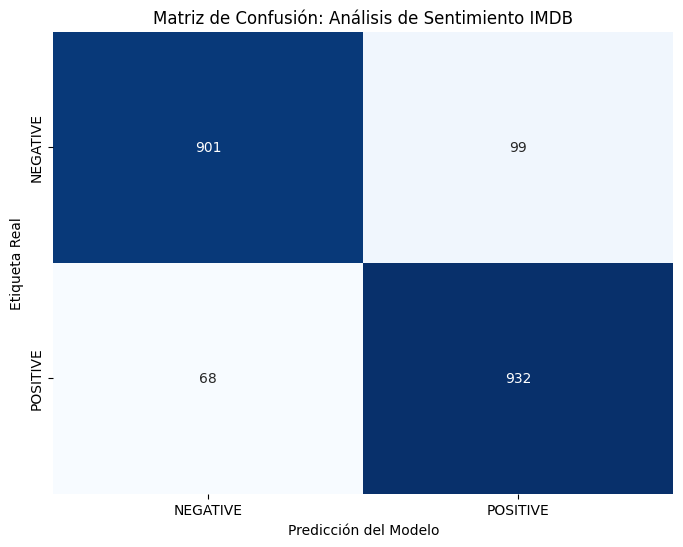

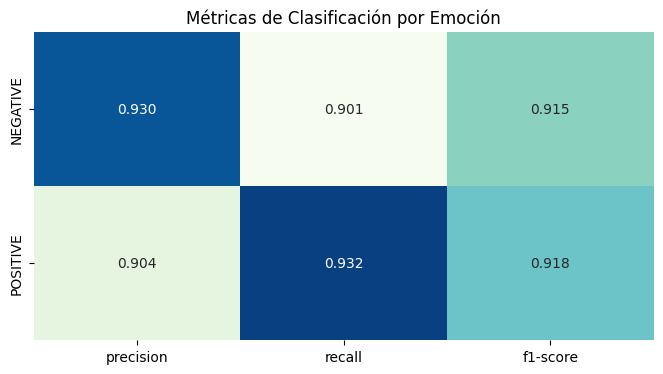

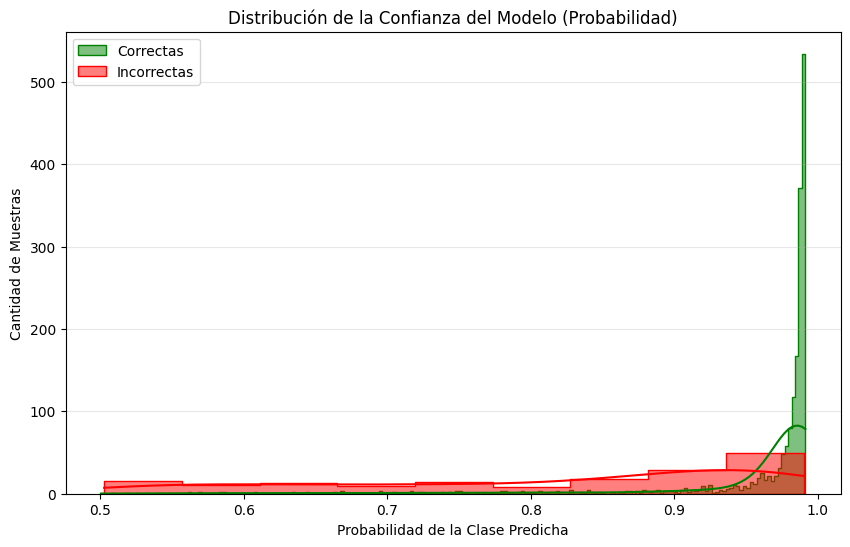


¡Gráficas generadas exitosamente!
Archivos guardados para tu GitHub:
1. confusion_matrix.png
2. classification_report.png
3. model_confidence_histogram.png


In [4]:
# =================================================================
# NUEVA CELDA: VISUALIZACIONES 
# =================================================================
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm # Para barra de progreso

# 1. Configuración de Dispositivo y Carga del Modelo Entrenado
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Generando análisis en: {device}")

# Ruta donde guardamos el modelo en el paso anterior
model_path = "/kaggle/working/modelo_emociones_imdb"

print("Cargando modelo y tokenizador guardados...")
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path).to(device)
model.eval() # Modo evaluación

# 2. Preparar Datos de Prueba 
print(f"Preparando {len(test_ds)} muestras de prueba...")

# 3. Inferencia en Lotes (Batches) para sacar predicciones completas
true_labels = []
pred_labels = []
pred_scores = [] # Guardaremos la probabilidad de la clase ganadora

batch_size = 32
# Usamos un DataLoader simple para iterar rápido
from torch.utils.data import DataLoader
test_loader = DataLoader(test_ds, batch_size=batch_size)

print("Corriendo inferencia sobre el dataset de prueba...")
with torch.no_grad():
    for batch in tqdm(test_loader):
        # Mover inputs a GPU
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        # Inferencia
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        
        # Calcular probabilidades (Softmax)
        probs = torch.nn.functional.softmax(logits, dim=-1)
        
        # Obtener predicciones y puntuaciones
        top_probs, top_preds = torch.max(probs, dim=1)
        
        # Guardar resultados
        true_labels.extend(labels.cpu().numpy())
        pred_labels.extend(top_preds.cpu().numpy())
        pred_scores.extend(top_probs.cpu().numpy())

# Convertir a arrays de numpy para sklearn
true_labels = np.array(true_labels)
pred_labels = np.array(pred_labels)
class_names = ['NEGATIVE', 'POSITIVE']

print("\n--- ¡Inferencia Completa! Generando Gráficas ---")

# =========================
# GRÁFICA 1: Matriz de Confusión
# =========================
plt.figure(figsize=(8, 6))
cm = confusion_matrix(true_labels, pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión: Análisis de Sentimiento IMDB')
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight') # Guardar para GitHub
plt.show()

# =========================
# GRÁFICA 2: Reporte de Clasificación Visual
# =========================
report = classification_report(true_labels, pred_labels, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).transpose().iloc[:-3, :-1] # Limpiar para gráfica

plt.figure(figsize=(8, 4))
sns.heatmap(report_df, annot=True, cmap='GnBu', cbar=False, fmt='.3f')
plt.title('Métricas de Clasificación por Emoción')
plt.savefig('classification_report.png', dpi=300, bbox_inches='tight')
plt.show()

# =========================
# GRÁFICA 3: Histograma de Confianza (Probabilidades)
# =========================
# Creamos un DataFrame para filtrar por aciertos/errores
results_df = pd.DataFrame({
    'true': true_labels,
    'pred': pred_labels,
    'score': pred_scores
})
results_df['correct'] = results_df['true'] == results_df['pred']

plt.figure(figsize=(10, 6))
# Histograma de scores para predicciones correctas
sns.histplot(data=results_df[results_df['correct'] == True], x='score', 
             color='green', label='Correctas', kde=True, element="step", alpha=0.5)
# Histograma de scores para predicciones incorrectas
sns.histplot(data=results_df[results_df['correct'] == False], x='score', 
             color='red', label='Incorrectas', kde=True, element="step", alpha=0.5)

plt.title('Distribución de la Confianza del Modelo (Probabilidad)')
plt.xlabel('Probabilidad de la Clase Predicha')
plt.ylabel('Cantidad de Muestras')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig('model_confidence_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n¡Gráficas generadas exitosamente!")
print("Archivos guardados para tu GitHub:")
print("1. confusion_matrix.png")
print("2. classification_report.png")
print("3. model_confidence_histogram.png")

In [9]:
# =================================================================
# CELDA DE TABLA DE EJEMPLOS
# =================================================================
import pandas as pd
from IPython.display import display

# 1. Seleccionar 20 muestras aleatorias
random_samples = test_ds.shuffle(seed=10).select(range(20))

samples_data = []

print("Procesando muestras...")

# Usamos .formatted_as(None) para recuperar acceso temporal al texto original
with random_samples.formatted_as(None):
    for i in range(len(random_samples)):
        # Ahora accedemos sin problemas
        text = random_samples[i]['text']
        label_num = random_samples[i]['labels'] 
        
        label_real = "POSITIVE" if label_num == 1 else "NEGATIVE"
        
        # Predicción de la IA
        label_ai = predict(text)
        
        # Limpieza de texto para que quepa en la tabla
        clean_text = text.replace("<br />", " ")
        text_preview = clean_text[:120] + "..." if len(clean_text) > 120 else clean_text
        
        # Comparación
        match = "✅" if label_real == label_ai else "❌"
        
        samples_data.append({
            "Texto de la Reseña": text_preview,
            "Etiqueta Real": label_real,
            "Predicción AI": label_ai,
            "Resultado": match
        })

# 2. Crear y mostrar la tabla
df_samples = pd.DataFrame(samples_data)

# Mostrar la tabla formateada
display(df_samples)

# 3. Guardar el archivo para descargar
df_samples.to_csv("muestras_resultados.csv", index=False)
print(f"\n¡Listo! Se procesaron {len(df_samples)} muestras.")

Procesando muestras...


,Texto de la Reseña,Etiqueta Real,Predicción AI,Resultado
0,It's 2 stars only because they put a lot of wo...,NEGATIVE,NEGATIVE,✅
1,OK I watched this movie. Someone needs to kick...,NEGATIVE,NEGATIVE,✅
2,"This movie was horrible, and it doesn't even d...",NEGATIVE,NEGATIVE,✅
3,Less a thriller than an colorful adventure wit...,POSITIVE,POSITIVE,✅
4,Three words: Piece of Art. This film is just g...,POSITIVE,POSITIVE,✅
5,Kokoda was inspired by events on the Kokoda tr...,NEGATIVE,NEGATIVE,✅
6,As a veteran screen writing instructor at Rich...,POSITIVE,POSITIVE,✅
7,"The problem with making a movie like this, tho...",NEGATIVE,NEGATIVE,✅
8,When I started watching 3 of the episodes of t...,POSITIVE,POSITIVE,✅
9,Screening as part of a series of funny shorts ...,POSITIVE,POSITIVE,✅



¡Listo! Se procesaron 20 muestras.
